In [5]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("spam_email_dataset.csv")

# Show first 5 rows
df.head()

,text,label
0,"Hi Arjun, just confirming our meeting schedule...",ham
1,Exclusive deal just for you! Get a huge discou...,spam
2,Congratulations winner! You qualify for a free...,spam
3,"Hi Pooja, thanks for your message. I will chec...",ham
4,"Hi Rahul, just confirming our meeting schedule...",ham


In [6]:
# Check dataset size
print("Dataset Shape:", df.shape)

# Check column names
print("Columns:", df.columns.tolist())

# Check Spam and Ham count
print("\nLabel Distribution:")
print(df["label"].value_counts())

Dataset Shape: (1200, 2)
Columns: ['text', 'label']

Label Distribution:
label
ham     600
spam    600
Name: count, dtype: int64


In [7]:
# Remove missing values
df = df.dropna(subset=["text", "label"]).copy()

# Convert email text to string
df["text"] = df["text"].astype(str)

# Remove extra spaces
df["text"] = df["text"].str.strip()

# Remove empty emails
df = df[df["text"] != ""]

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (1200, 2)


In [8]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Separate email text and labels
X = df["text"]
y = df["label"]

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 960
Testing samples: 240


In [9]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

# Convert training and testing emails into numerical features
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF conversion completed!")
print("Training feature shape:", X_train_tfidf.shape)

TF-IDF conversion completed!
Training feature shape: (960, 154)


In [10]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the classification model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [11]:
# Make predictions on test emails
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
['spam' 'spam' 'ham' 'ham' 'ham' 'ham' 'spam' 'spam' 'ham' 'ham']


In [12]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       120
        spam       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



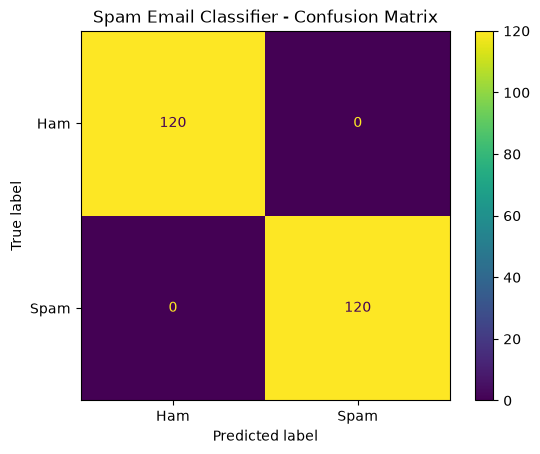

In [13]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["ham", "spam"]
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Spam Email Classifier - Confusion Matrix")
plt.show()

In [14]:
# Create new email examples
new_emails = [
    "Congratulations! You have won a free prize. Click now to claim your reward.",
    "Hi, please send me the project report before tomorrow morning."
]

# Convert new emails into TF-IDF features
new_features = tfidf.transform(new_emails)

# Predict the category
new_predictions = model.predict(new_features)

# Display results
for email, prediction in zip(new_emails, new_predictions):
    print("Email:", email)
    print("Prediction:", prediction.upper())
    print("-" * 60)

Email: Congratulations! You have won a free prize. Click now to claim your reward.
Prediction: SPAM
------------------------------------------------------------
Email: Hi, please send me the project report before tomorrow morning.
Prediction: HAM
------------------------------------------------------------


In [15]:
# Import joblib
import joblib

# Save the trained model
joblib.dump(model, "spam_email_classifier.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
